#  Atelier Scikit-learn 
Contexte 
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression, la consommation énergétique, le bâtiment, la date et l'heure de la mesure.  Chaque mesure possède également un état (OK, ALERTE et ERREUR). L'objectif de l'atelier est de construire un modèle capable de prédire automatiquement l'état d'un capteur à partir de ses mesures. L'atelier suivra le workflow classique du Machine Learning : Dataset → Chargement → Exploration → Nettoyage → X / y → Train / Test → Prétraitement → Modèle → fit()→ predict()→ Évaluation → Sauvegarde → Chargement → Réutilisation 

# Partie 0 – mise en place de l’environnement 
1) Structurer le projet comme suit : 

2) Stocker le fichier fourni mesures_capteurs.csv dans le sous-dossier data 
3) Créer le notebook atelier_scikit-learn_iot.ipynb 
4) Installer et importer seaborn, matplotlib et pandas 
5) Importer mesures_capteurs.csv dans le dataframe df 
6) Explorer le dataframe df 

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [67]:
df.shape

(605, 9)

# Partie 1 – Gestion des doublons Avec Pandas, 
1) vérifier l’existence de doublons dans df 
2) le cas échéant, supprimer les doublons puis vérifier la suppression  

## 1) vérifier l’existence de doublons dans df 


In [68]:
print("Nombre de doublons :", df.duplicated().sum())


Nombre de doublons : 5


## 2) le cas échéant, supprimer les doublons puis vérifier la suppression  

In [69]:
df = df.drop_duplicates()
print("Nouvelles dimensions :", df.shape)

Nouvelles dimensions : (600, 9)


# Partie 2 – Sélection de y (cible) et X (caractéristiques) 
1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives 
2) Afficher les cinq premières lignes de X et de y 
3) Quel est le type du problème de machine learning ?  

## 1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives 

In [70]:
# 1) D'abord nettoyer df
df = df.dropna(subset=["etat"])

# 2) SEULEMENT APRÈS, recréer X et y à partir du df nettoyé
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

print("Nouvelle taille de y :", y.shape)
print("Valeurs uniques de y :", y.unique())

Nouvelle taille de y : (596,)
Valeurs uniques de y : <StringArray>
['OK', 'ALERTE', 'ERREUR']
Length: 3, dtype: str


## 2) Afficher les cinq premières lignes de X et de y 


In [71]:
print("les features")
print(X.head())
print("la cible")
print(y.head())

les features
   temperature  humidite  pression  consommation
0        25.46     58.06   1008.95        287.28
1        24.00     79.73    993.39        116.20
2        25.82     54.47   1010.32        288.50
3        28.23     69.39   1019.62        136.65
4        20.58     53.80   1016.58        182.62
la cible
0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str


In [72]:
# les elements de atat 
y.unique() 

<StringArray>
['OK', 'ALERTE', 'ERREUR']
Length: 3, dtype: str

## 3) Quel est le type du problème de machine learning ?  
Il s'agit d'un problème de classification multi-classes : la cible "etat" contient 3 
catégories possibles (OK, ALERTE, ERREUR), pas un nombre continu à prédire.

# Partie 3 – Découpage Train/Test Diviser X en deux ensembles distincts :
 un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que dans les données d'origine. 

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 20% des données pour le test
    random_state=42,      # garantir la reproductibilité
    stratify=y            # conserver les mêmes proportions de classes
)

print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)

Taille X_train : (476, 4)
Taille X_test  : (120, 4)


In [74]:
y_train.unique()

<StringArray>
['OK', 'ALERTE', 'ERREUR']
Length: 3, dtype: str

In [75]:
y_test.unique()

<StringArray>
['OK', 'ALERTE', 'ERREUR']
Length: 3, dtype: str

# Partie 4 – Gestion des valeurs manquantes 
1) Vérifier l’existence de valeurs manquantes 
2) Sélectionner SimpleImputer avec la médiane 
3) Qu’est ce qui justifie le choix de la médiane ? 
4) Trouver les paramètres (médianes) de l’imputeur sur X_train 
5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test 

## 1) Vérifier l’existence de valeurs manquantes 


In [76]:
print("Valeurs manquantes dans X_train :")
print(X_train.isnull().sum())
print("\nValeurs manquantes dans X_test :")
print(X_test.isnull().sum())

Valeurs manquantes dans X_train :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

Valeurs manquantes dans X_test :
temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


## 2) Sélectionner SimpleImputer avec la médiane 


In [77]:
# Création de l'imputeur, configuré pour remplacer par la MEDIANE

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

## 3) Qu’est ce qui justifie le choix de la médiane ? 

La médiane est moins sensible aux valeurs extrêmes que la moyenne. Rappelle-toi les 
anomalies déjà identifiées dans ce dataset (température ~-18°C ou ~58°C, liées à 
B004) : si on utilisait la moyenne pour imputer, ces valeurs aberrantes tireraient 
la moyenne dans leur direction, faussant les valeurs de remplacement. La médiane 
reste stable face à ces cas isolés.

## 4) Trouver les paramètres (médianes) de l’imputeur sur X_train 


In [78]:
# fit() calcule les médianes UNIQUEMENT sur X_train, jamais sur X_test,
# pour éviter toute fuite de données (data leakage) vers le jeu de test
imputer.fit(X_train)
print("Médianes calculées sur X_train :", imputer.statistics_)

Médianes calculées sur X_train : [  24.9    65.38 1012.3   206.59]


## 5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test 

In [79]:
# transform() applique ensuite ces mêmes médianes à train ET à test
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [80]:
print("Valeurs manquantes restantes (train) :", pd.DataFrame(X_train_imputed).isnull().sum().sum())
print("Valeurs manquantes restantes (test)  :", pd.DataFrame(X_test_imputed).isnull().sum().sum())

Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test)  : 0


# Partie 5 – Mise à l'échelle 
1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation 
2) Qu’est ce qui justifie la standardisation ? 
3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed 
4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed 

## 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation 


In [81]:
from sklearn.preprocessing import StandardScaler

# Création du scaler, configuré pour centrer-réduire (standardisation)
scaler = StandardScaler()

## 2) Qu’est ce qui justifie la standardisation ? 

La standardisation est moins sensible aux valeurs extrêmes que la normalisation 
Min-Max. Rappelle-toi les anomalies déjà identifiées (température ~-18°C ou ~58°C) : 
avec une normalisation Min-Max, ces valeurs extrêmes deviendraient le nouveau min/max, 
écrasant l'échelle de toutes les autres mesures normales vers un intervalle très 
restreint. La standardisation reste plus stable face à ce type de cas.


## 3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed 


In [82]:
# fit() calcule moyenne et écart-type UNIQUEMENT sur X_train_imputed,
# pour la même raison qu'avec l'imputer : éviter la fuite de données vers le test
scaler.fit(X_train_imputed)

print("Moyennes calculées sur X_train_imputed :", scaler.mean_)
print("Écarts-types calculés :", scaler.scale_)

Moyennes calculées sur X_train_imputed : [  24.9637395    64.85044118 1012.07621849  210.15394958]
Écarts-types calculés : [ 4.19303979 10.16279173 10.9941836  73.42092322]


## 4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed 

In [83]:
# transform() applique ensuite ces mêmes paramètres à train ET à test
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Vérification : après standardisation, la moyenne doit être ~0 et l'écart-type ~1
print("Moyenne après scaling (train) :", X_train_scaled.mean(axis=0).round(2))
print("Écart-type après scaling (train) :", X_train_scaled.std(axis=0).round(2))

Moyenne après scaling (train) : [-0.  0. -0.  0.]
Écart-type après scaling (train) : [1. 1. 1. 1.]


# Partie 6 – Entrainement et prédiction d’un modèle 
1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte 
2) Entrainer le modèle 
3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test 
4) Afficher quelques prédictions 
5) Comparer ces prédictions avec les vraies valeurs 

## 1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte 


In [84]:
from sklearn.neighbors import KNeighborsClassifier

#  Sélection du modèle KNN avec 5 voisins
# (n_neighbors=5 : pour prédire l'état d'une nouvelle mesure, le modèle regarde
# les 5 mesures les plus "proches" déjà connues, et vote pour l'état majoritaire)
modele = KNeighborsClassifier(n_neighbors=5)

## 2) Entrainer le modèle 


In [85]:
# Entraînement : le modèle "mémorise" X_train_scaled et y_train
# (rappel : pour KNN, "entraîner" ne calcule pas de poids, il garde
# simplement toutes les données d'entraînement en mémoire pour comparer)
modele.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test 


In [86]:
# Prédiction sur les données de test (jamais vues par le modèle)
y_pred = modele.predict(X_test_scaled)


## 4) Affichage de quelques prédictions

In [87]:
# 4) Affichage de quelques prédictions
print("Premières prédictions :", y_pred[:10])

Premières prédictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


## 5) Comparer ces prédictions avec les vraies valeurs 

In [89]:
comparaison = pd.DataFrame({
    "Vraie valeur": y_test.values[:10],
    "Prédiction": y_pred[:10]
})
print(comparaison)

  Vraie valeur Prédiction
0           OK         OK
1           OK         OK
2           OK         OK
3           OK         OK
4       ALERTE         OK
5           OK         OK
6           OK         OK
7           OK         OK
8           OK         OK
9           OK         OK


# Partie 7 – Evaluation du modèle
1) Evaluer le modèle avec Accuracy puis afficher le résultat
2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?
3) Déterminer, afficher et commenter la matrice de confusion
4) Visualiser cette matrice avec Seaborn
5) Afficher et commenter le rapport de classificaton
6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même
question avec recall; même question avec F1 score; même question avec accuracy

## 1) Evaluer le modèle avec Accuracy puis afficher le résultat


In [90]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.9583333333333334


## 2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?

Avec ~94% de mesures "OK" dans le dataset, un modèle qui prédirait TOUJOURS "OK", 
sans jamais rien apprendre, obtiendrait déjà une accuracy d'environ 94%. L'accuracy 
seule ne dit rien sur la capacité du modèle à détecter les cas rares mais critiques 
(ALERTE, ERREUR) - exactement ce qu'on a observé concrètement (une vraie ALERTE 
prédite comme OK).

## 3) Déterminer, afficher et commenter la matrice de confusion


In [91]:
from sklearn.metrics import confusion_matrix

# On précise l'ordre des classes pour que la matrice soit lisible dans un ordre logique
matrice = confusion_matrix(y_test, y_pred, labels=["OK", "ALERTE", "ERREUR"])
print(matrice)

[[113   0   0]
 [  4   2   0]
 [  0   1   0]]


 Commentaire de la matrice de confusion

Le modèle prédit parfaitement les mesures OK (113/113). Il semble en revanche avoir 
du mal avec les classes rares : sur 6 vraies alertes, seulement 2 sont détectées, 
les 4 autres étant classées à tort comme OK. La seule vraie erreur du jeu de test 
est classée comme ALERTE, jamais comme ERREUR.

→ Ça confirme concrètement ce que l'accuracy seule aurait caché : le modèle est 
très bon pour reconnaître le fonctionnement normal, mais peu fiable pour détecter 
les vraies anomalies - exactement l'objectif recherché dans ce projet.

## 4) Visualiser cette matrice avec Seaborn


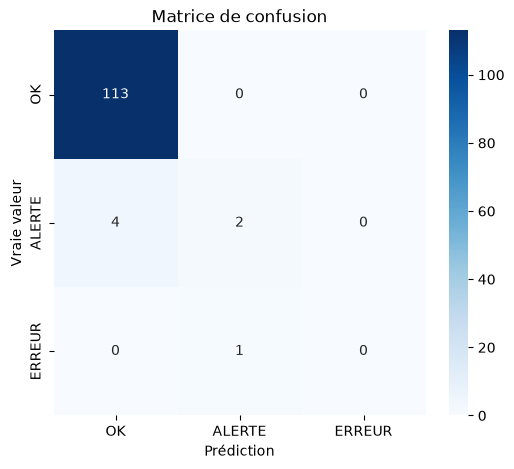

In [92]:
plt.figure(figsize=(6, 5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=["OK", "ALERTE", "ERREUR"],
            yticklabels=["OK", "ALERTE", "ERREUR"])
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.title("Matrice de confusion")
plt.show()

## 5) Afficher et commenter le rapport de classificaton


In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\DELL\Desktop\sonatel academy\python ML et IA  2\atelier_scikit-learn_iot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\Desktop\sonatel academy\python ML et IA  2\atelier_scikit-learn_iot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\Desktop\sonatel academy\python ML et IA  2\atelier_scikit-learn_iot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels wi



Le modèle est excellent sur OK (precision 0.97, recall 1.00), mais faible sur 
ALERTE (recall de seulement 0.33 - 2 alertes sur 6 détectées) et totalement 
absent sur ERREUR (0 dans toutes les métriques - jamais prédite).

→ Le "macro avg" (0.48 de F1, moyenne simple entre les 3 classes) révèle la vraie 
faiblesse du modèle sur les cas rares, alors que l'accuracy (0.96) et le "weighted 
avg" (dominés par la classe OK très majoritaire) donnent une fausse impression 
de bonne performance globale.

## 6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même
## question avec recall; même question avec F1 score; même question avec accuracy

- Precision : quand une fausse alerte coûte cher (tu veux être sûre qu'une 
  prédiction d'ALERTE est vraiment une alerte, pas un faux positif).

- Recall : quand rater un vrai cas est grave - typiquement ICI, rater une vraie 
  panne (ERREUR) est plus coûteux qu'une fausse alerte.

- F1-score : quand tu veux un compromis entre precision et recall, notamment 
  si les classes sont déséquilibrées comme ici.

- Accuracy : seulement quand les classes sont équilibrées - ce qui n'est PAS 
  le cas de ce dataset.
